# Лабораторная работа №5
## Эволюционное проектирование адаптивных ансамблей (Smart Ensemble)
---

## 1. Импорт библиотек

In [1]:
import numpy as np
import random
import copy
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

I0000 00:00:1780549077.064563  305393 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0


I0000 00:00:1780549078.085554  305393 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 2. Загрузка и подготовка данных

In [2]:
# Тот же набор данных Covertype (Big Data), что и в ЛР4
data = fetch_covtype()
X_full, y_full = data.data, data.target - 1

print(f"Полный датасет: {X_full.shape[0]} образцов, {X_full.shape[1]} признаков, {len(np.unique(y_full))} классов")

# Сбалансированная выборка 30 000 образцов
SAMPLE_SIZE = 30_000
idx = []
for cls in np.unique(y_full):
    cls_idx = np.where(y_full == cls)[0]
    n = int(SAMPLE_SIZE * len(cls_idx) / len(y_full))
    idx.extend(np.random.choice(cls_idx, size=n, replace=False).tolist())

random.shuffle(idx)
X, y = X_full[idx], y_full[idx]

# Разбивка: 60% train / 20% val / 20% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.40, random_state=42, stratify=y)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

N_FEATURES = X_train.shape[1]
N_CLASSES  = len(np.unique(y))

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")
print(f"Признаков: {N_FEATURES}, Классов: {N_CLASSES}")

Полный датасет: 581012 образцов, 54 признаков, 7 классов
Train: 17998, Val: 5999, Test: 6000
Признаков: 54, Классов: 7


## 3. Пул моделей-экспертов

Создаём **6 экспертных моделей** с различными архитектурами:
- разная глубина (1–4 слоя), функции активации (relu, tanh, elu, selu), L2-регуляризация, Dropout


In [3]:
# (id, neurons, activation, l2_reg, dropout)
EXPERT_CONFIGS = [
    (0, [128, 64],           'relu', 1e-4, 0.2),
    (1, [256, 128, 64],      'tanh', 5e-4, 0.3),
    (2, [64],                'elu',  1e-3, 0.0),
    (3, [512, 256, 128, 64], 'relu', 1e-5, 0.1),
    (4, [128, 128],          'selu', 1e-4, 0.2),
    (5, [256, 64],           'tanh', 5e-3, 0.3),
]
N_EXPERTS = len(EXPERT_CONFIGS)


def build_expert(config):
    _, neurons, activation, l2_reg, dropout = config
    model = Sequential()
    for i, n in enumerate(neurons):
        if i == 0:
            model.add(Dense(n, activation=activation,
                            kernel_regularizer=l2(l2_reg),
                            input_shape=(N_FEATURES,)))
        else:
            model.add(Dense(n, activation=activation,
                            kernel_regularizer=l2(l2_reg)))
        model.add(BatchNormalization())
        if dropout > 0:
            model.add(Dropout(dropout))
    model.add(Dense(N_CLASSES, activation='softmax'))
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


print(f"Пул из {N_EXPERTS} экспертных моделей определён")

Пул из 6 экспертных моделей определён


## 4. Обучение экспертных моделей

In [4]:
TRAIN_EPOCHS = 30
BATCH_SIZE   = 256

expert_models    = []
expert_val_accs  = []
expert_histories = []

early_stop = EarlyStopping(monitor='val_accuracy', patience=5,
                            restore_best_weights=True, verbose=0)

for cfg in EXPERT_CONFIGS:
    mid, neurons, activation, l2_reg, dropout = cfg
    print(f"  Обучение модели #{mid}: {neurons}, {activation}, l2={l2_reg}, drop={dropout}")
    m = build_expert(cfg)
    h = m.fit(X_train, y_train,
              validation_data=(X_val, y_val),
              epochs=TRAIN_EPOCHS, batch_size=BATCH_SIZE,
              callbacks=[early_stop], verbose=0)
    expert_models.append(m)
    expert_histories.append(h)
    val_acc = max(h.history['val_accuracy'])
    expert_val_accs.append(val_acc)
    print(f"    -> val_accuracy = {val_acc:.4f}")

best_single_idx = int(np.argmax(expert_val_accs))
best_single_acc = expert_val_accs[best_single_idx]
print(f"\nЛучшая одиночная модель: #{best_single_idx}, val_accuracy = {best_single_acc:.4f}")

  Обучение модели #0: [128, 64], relu, l2=0.0001, drop=0.2
    -> val_accuracy = 0.7756
  Обучение модели #1: [256, 128, 64], tanh, l2=0.0005, drop=0.3
    -> val_accuracy = 0.7370
  Обучение модели #2: [64], elu, l2=0.001, drop=0.0
    -> val_accuracy = 0.7196
  Обучение модели #3: [512, 256, 128, 64], relu, l2=1e-05, drop=0.1
    -> val_accuracy = 0.7421
  Обучение модели #4: [128, 128], selu, l2=0.0001, drop=0.2
    -> val_accuracy = 0.7291
  Обучение модели #5: [256, 64], tanh, l2=0.005, drop=0.3
    -> val_accuracy = 0.7376

Лучшая одиночная модель: #0, val_accuracy = 0.7756


## 5. Генотип особи — стратегия управления ансамблем

Каждая **особь** кодирует стратегию «дирижёра»:
- `active_mask` — бинарный вектор включения каждого из 6 экспертов;
- `rules` — список порогов (feat_idx, threshold, group) для переключения режима;
- `weights_0` / `weights_1` — веса моделей в режимах «Стабильность» и «Риск».


In [5]:
# Определяем непрерывные признаки по числу уникальных значений в ИСХОДНЫХ данных
# (до StandardScaler — скейлер не меняет число уникальных значений)
n_unique = np.array([len(np.unique(X_full[:, i])) for i in range(X_full.shape[1])])

# Непрерывный = > 20 уникальных значений (бинарные/категориальные имеют <=10)
continuous_idx = np.where(n_unique > 20)[0].tolist()
print(f"Непрерывных признаков (>20 уникальных): {len(continuous_idx)}")
print(f"Индексы: {continuous_idx}")

# Топ-5 по дисперсии (в нормализованных данных)
feature_variances = X_train.var(axis=0)
TOP_FEAT_INDICES  = sorted(continuous_idx,
                            key=lambda i: feature_variances[i],
                            reverse=True)[:5]
print("Топ-5 непрерывных признаков по дисперсии:", TOP_FEAT_INDICES)
print("Диапазоны (нормализованные):",
      [(i, round(float(X_train[:,i].min()),2), round(float(X_train[:,i].max()),2))
       for i in TOP_FEAT_INDICES])

# Для КАРТЫ РЕШЕНИЙ используем признаки с наибольшим разбросом в val-выборке
# и берём оба непрерывных с наибольшей дисперсией
MAP_FEAT_A = TOP_FEAT_INDICES[0]
MAP_FEAT_B = TOP_FEAT_INDICES[1]
print(f"\nПризнаки для карты решений: X{MAP_FEAT_A} и X{MAP_FEAT_B}")


def random_individual():
    """Особь: active_mask (мин. 2 активных) + rules + weights_0/1."""
    while True:
        active_mask = [random.randint(0, 1) for _ in range(N_EXPERTS)]
        if sum(active_mask) >= 2:
            break

    n_rules = random.randint(1, 3)
    rules   = []
    for _ in range(n_rules):
        feat = random.choice(TOP_FEAT_INDICES)
        vals = X_train[:, feat]
        thr  = float(np.random.uniform(np.percentile(vals, 20),
                                        np.percentile(vals, 80)))
        grp  = random.randint(0, 1)
        rules.append((feat, thr, grp))

    w0 = np.random.dirichlet(np.ones(N_EXPERTS)).tolist()
    w1 = np.random.dirichlet(np.ones(N_EXPERTS)).tolist()

    return {
        'active_mask': active_mask,
        'rules':       rules,
        'weights_0':   w0,
        'weights_1':   w1,
    }


def apply_strategy(individual, X_batch, proba_matrix):
    """
    Дирижёр: для каждого образца определяет режим (0/1)
    и формирует взвешенную сумму вероятностей активных экспертов.
    proba_matrix: (N_EXPERTS, n_samples, N_CLASSES)
    """
    n      = X_batch.shape[0]
    active = np.array(individual['active_mask'], dtype=float)

    sample_group = np.zeros(n, dtype=int)
    for (feat, thr, grp) in individual['rules']:
        mask = X_batch[:, feat] > thr
        sample_group[mask] = grp

    result = np.zeros((n, N_CLASSES))
    for g in [0, 1]:
        idx_g = np.where(sample_group == g)[0]
        if len(idx_g) == 0:
            continue
        w = np.array(individual[f'weights_{g}']) * active
        s = w.sum()
        w = w / s if s > 0 else active / active.sum()
        contrib = np.einsum('e,ecl->cl', w, proba_matrix[:, idx_g, :])
        result[idx_g] = contrib

    return np.argmax(result, axis=1)


ind_ex = random_individual()
print("\nПример особи — active_mask:", ind_ex['active_mask'],
      "| активных:", sum(ind_ex['active_mask']))


Непрерывных признаков (>20 уникальных): 10
Индексы: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Топ-5 непрерывных признаков по дисперсии: [2, 1, 4, 9, 7]
Диапазоны (нормализованные): [(2, -1.87, 4.9), (1, -1.39, 1.84), (4, -3.39, 8.44), (9, -1.49, 3.87), (7, -6.96, 1.56)]

Признаки для карты решений: X2 и X1

Пример особи — active_mask: [1, 1, 0, 1, 0, 1] | активных: 4


## 6. Фитнес-функция

$$F = \text{Accuracy} - \text{штраф} \times \text{число активных моделей}$$

Штраф за избыточность = 0.01 за каждую активную модель.


In [6]:
REDUNDANCY_PENALTY = 0.005   # было 0.01 — слишком сильно давило в пользу 1 модели

print("Предвычисление вероятностей экспертов на val-наборе...")
val_proba_matrix = np.array([
    m.predict(X_val, verbose=0) for m in expert_models
])
print(f"Матрица вероятностей: {val_proba_matrix.shape}  (experts x samples x classes)")


def fitness(individual):
    y_pred   = apply_strategy(individual, X_val, val_proba_matrix)
    acc      = accuracy_score(y_val, y_pred)
    n_active = sum(individual['active_mask'])
    return acc - REDUNDANCY_PENALTY * n_active


ind_test = random_individual()
print(f"Фитнес случайной особи: {fitness(ind_test):.4f}")


Предвычисление вероятностей экспертов на val-наборе...
Матрица вероятностей: (6, 5999, 7)  (experts x samples x classes)
Фитнес случайной особи: 0.7250


## 7. Операторы генетического алгоритма

- **Турнирная селекция** (k=3)
- **Двухточечное скрещивание** (маска, правила, веса)
- **Мутация** порогов, масок активации и весов


In [7]:
def tournament_selection(population, fitnesses, k=3):
    candidates = random.sample(range(len(population)), k)
    best = max(candidates, key=lambda i: fitnesses[i])
    return copy.deepcopy(population[best])


def crossover(p1, p2):
    child = {}
    mask = [random.choice([a, b]) for a, b in zip(p1['active_mask'], p2['active_mask'])]
    while sum(mask) < 2:
        mask[random.randint(0, N_EXPERTS - 1)] = 1
    child['active_mask'] = mask

    pool = p1['rules'] + p2['rules']
    n    = random.randint(1, min(3, len(pool)))
    child['rules'] = random.sample(pool, n)

    alpha = random.random()
    child['weights_0'] = [alpha * a + (1 - alpha) * b
                          for a, b in zip(p1['weights_0'], p2['weights_0'])]
    child['weights_1'] = [alpha * a + (1 - alpha) * b
                          for a, b in zip(p1['weights_1'], p2['weights_1'])]
    return child


def mutate(individual, mutation_rate=0.30):
    ind = copy.deepcopy(individual)

    if random.random() < mutation_rate:
        i = random.randint(0, N_EXPERTS - 1)
        ind['active_mask'][i] ^= 1
        if sum(ind['active_mask']) < 2:
            ind['active_mask'][i] = 1

    if random.random() < mutation_rate and ind['rules']:
        j = random.randint(0, len(ind['rules']) - 1)
        feat, thr, grp = ind['rules'][j]
        # Смещаем порог в пределах реального диапазона признака
        vals   = X_train[:, feat]
        thr   += np.random.normal(0, (vals.max() - vals.min()) * 0.1)
        thr    = float(np.clip(thr, vals.min(), vals.max()))
        if random.random() < 0.3:
            feat = random.choice(TOP_FEAT_INDICES)
        if random.random() < 0.2:
            grp = 1 - grp
        ind['rules'][j] = (feat, thr, grp)

    if random.random() < mutation_rate * 0.5:
        if len(ind['rules']) < 3:
            feat = random.choice(TOP_FEAT_INDICES)
            vals = X_train[:, feat]
            thr  = float(np.random.uniform(np.percentile(vals, 20),
                                            np.percentile(vals, 80)))
            ind['rules'].append((feat, thr, random.randint(0, 1)))
        elif len(ind['rules']) > 1:
            ind['rules'].pop(random.randint(0, len(ind['rules']) - 1))

    if random.random() < mutation_rate:
        for key in ['weights_0', 'weights_1']:
            w = np.array(ind[key]) + np.random.normal(0, 0.15, N_EXPERTS)
            w = np.clip(w, 0, None)
            s = w.sum()
            ind[key] = (w / s if s > 0 else np.ones(N_EXPERTS) / N_EXPERTS).tolist()

    return ind


print("Операторы GA определены")


Операторы GA определены


## 8. Главный цикл генетического алгоритма

In [8]:
POP_SIZE       = 20
N_GENERATIONS  = 30
ELITE_SIZE     = 2
MUTATION_RATE  = 0.30
CROSSOVER_PROB = 0.80

population = [random_individual() for _ in range(POP_SIZE)]

history_best_fitness = []
history_mean_fitness = []
history_best_acc     = []

best_individual  = None
best_fitness_val = -np.inf

print(f"Генетический алгоритм: популяция={POP_SIZE}, поколений={N_GENERATIONS}")
print("=" * 60)

for gen in range(N_GENERATIONS):
    fitnesses = [fitness(ind) for ind in population]

    gen_best_idx = int(np.argmax(fitnesses))
    if fitnesses[gen_best_idx] > best_fitness_val:
        best_fitness_val = fitnesses[gen_best_idx]
        best_individual  = copy.deepcopy(population[gen_best_idx])

    y_pred_best = apply_strategy(best_individual, X_val, val_proba_matrix)
    acc_best    = accuracy_score(y_val, y_pred_best)

    history_best_fitness.append(best_fitness_val)
    history_mean_fitness.append(float(np.mean(fitnesses)))
    history_best_acc.append(acc_best)

    if (gen + 1) % 5 == 0 or gen == 0:
        n_act = sum(best_individual['active_mask'])
        print(f"Поколение {gen + 1:3d} | best_fitness={best_fitness_val:.4f}"
              f" | acc={acc_best:.4f} | active={n_act}")

    # Элитизм
    sorted_pop = [x for _, x in sorted(zip(fitnesses, population),
                                        key=lambda t: t[0], reverse=True)]
    new_population = sorted_pop[:ELITE_SIZE]

    while len(new_population) < POP_SIZE:
        p1 = tournament_selection(population, fitnesses)
        if random.random() < CROSSOVER_PROB:
            p2    = tournament_selection(population, fitnesses)
            child = crossover(p1, p2)
        else:
            child = copy.deepcopy(p1)
        child = mutate(child, MUTATION_RATE)
        new_population.append(child)

    population = new_population

print("=" * 60)
print(f"\nЭволюция завершена. Лучший фитнес: {best_fitness_val:.4f}")

Генетический алгоритм: популяция=20, поколений=30
Поколение   1 | best_fitness=0.7576 | acc=0.7726 | active=3
Поколение   5 | best_fitness=0.7656 | acc=0.7756 | active=2
Поколение  10 | best_fitness=0.7660 | acc=0.7760 | active=2
Поколение  15 | best_fitness=0.7663 | acc=0.7763 | active=2
Поколение  20 | best_fitness=0.7671 | acc=0.7771 | active=2
Поколение  25 | best_fitness=0.7673 | acc=0.7773 | active=2
Поколение  30 | best_fitness=0.7675 | acc=0.7775 | active=2

Эволюция завершена. Лучший фитнес: 0.7675


## 9. Визуализация: динамика эволюции

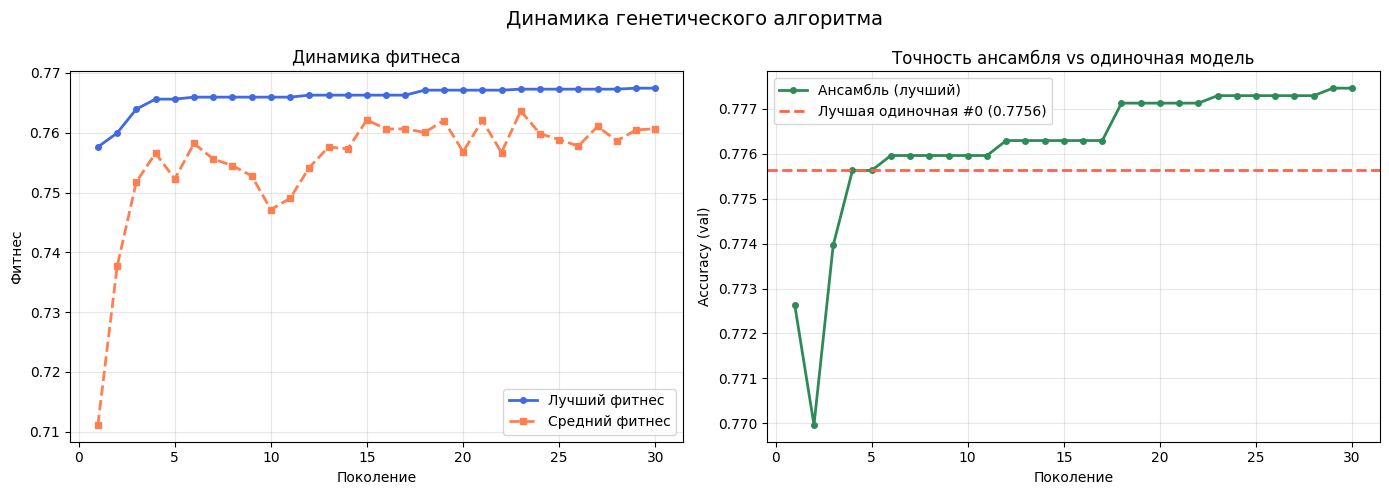

In [9]:
generations = list(range(1, N_GENERATIONS + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Динамика генетического алгоритма", fontsize=14)

ax = axes[0]
ax.plot(generations, history_best_fitness, 'o-', color='royalblue',
        linewidth=2, markersize=4, label='Лучший фитнес')
ax.plot(generations, history_mean_fitness, 's--', color='coral',
        linewidth=2, markersize=4, label='Средний фитнес')
ax.set_xlabel("Поколение")
ax.set_ylabel("Фитнес")
ax.set_title("Динамика фитнеса")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(generations, history_best_acc, 'o-', color='seagreen',
        linewidth=2, markersize=4, label='Ансамбль (лучший)')
ax.axhline(best_single_acc, color='tomato', linestyle='--', linewidth=2,
           label=f'Лучшая одиночная #{best_single_idx} ({best_single_acc:.4f})')
ax.set_xlabel("Поколение")
ax.set_ylabel("Accuracy (val)")
ax.set_title("Точность ансамбля vs одиночная модель")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Финальные результаты на тестовой выборке

In [10]:
# Матрица вероятностей на тест-наборе
print("Предвычисление вероятностей на тест-наборе...")
test_proba_matrix = np.array([
    m.predict(X_test, verbose=0) for m in expert_models
])

# Предсказания ансамбля
y_pred_ensemble = apply_strategy(best_individual, X_test, test_proba_matrix)
acc_ensemble    = accuracy_score(y_test, y_pred_ensemble)

# Предсказания лучшей одиночной модели
y_pred_single = np.argmax(expert_models[best_single_idx].predict(X_test, verbose=0), axis=1)
acc_single    = accuracy_score(y_test, y_pred_single)

n_active   = sum(best_individual['active_mask'])
active_ids = [i for i, v in enumerate(best_individual['active_mask']) if v == 1]

print("=" * 60)
print("  ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ")
print("=" * 60)
print(f"  Точность ансамбля (test):         {acc_ensemble:.4f}")
print(f"  Точность лучшей одиночной (test): {acc_single:.4f}")
print(f"  Прирост:                          {acc_ensemble - acc_single:+.4f}")
print(f"  Число активных моделей:           {n_active} из {N_EXPERTS}")
print(f"  Активные модели:                  {active_ids}")
print()
print("  Детали активных экспертов:")
for i in active_ids:
    cfg = EXPERT_CONFIGS[i]
    print(f"    Модель #{i}: layers={cfg[1]}, act={cfg[2]}, "
          f"l2={cfg[3]}, drop={cfg[4]}, val_acc={expert_val_accs[i]:.4f}")

Предвычисление вероятностей на тест-наборе...
  ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ
  Точность ансамбля (test):         0.7737
  Точность лучшей одиночной (test): 0.7722
  Прирост:                          +0.0015
  Число активных моделей:           2 из 6
  Активные модели:                  [0, 2]

  Детали активных экспертов:
    Модель #0: layers=[128, 64], act=relu, l2=0.0001, drop=0.2, val_acc=0.7756
    Модель #2: layers=[64], act=elu, l2=0.001, drop=0.0, val_acc=0.7196


## 11. Описание логики переключения (правила «дирижёра»)

In [11]:
feature_names = [f"X{i}" for i in range(N_FEATURES)]

print("ПРАВИЛА ПЕРЕКЛЮЧЕНИЯ (найденные эволюцией):")
print("-" * 60)

rules      = best_individual['rules']
w0         = best_individual['weights_0']
w1         = best_individual['weights_1']
active_ids = [i for i, v in enumerate(best_individual['active_mask']) if v == 1]

for j, (feat, thr, grp) in enumerate(rules):
    mode = '"Риск"' if grp == 1 else '"Стабильность"'
    print(f"  Правило {j + 1}: Если {feature_names[feat]} > {thr:.3f}  ->  режим {mode}")

print()
print('Режим "Стабильность" (группа 0):')
for mid in active_ids:
    print(f"  Модель #{mid}  вес = {w0[mid]:.3f}")

print()
print('Режим "Риск" (группа 1):')
for mid in active_ids:
    print(f"  Модель #{mid}  вес = {w1[mid]:.3f}")

# Вывод правил в формате задания
print()
print("Правила в формате задания:")
if rules:
    main1 = max(active_ids, key=lambda i: w1[i])
    main0 = max(active_ids, key=lambda i: w0[i])
    feat0, thr0, _ = rules[0]
    print(f"  -> Если {feature_names[feat0]} > {thr0:.3f}: доминирует Модель #{main1} (режим Риск)")
    print(f"  -> В остальных случаях: усредняются Модели {active_ids} (режим Стабильность)")

ПРАВИЛА ПЕРЕКЛЮЧЕНИЯ (найденные эволюцией):
------------------------------------------------------------
  Правило 1: Если X7 > 1.383  ->  режим "Риск"
  Правило 2: Если X1 > 0.982  ->  режим "Риск"
  Правило 3: Если X2 > -0.130  ->  режим "Стабильность"

Режим "Стабильность" (группа 0):
  Модель #0  вес = 0.217
  Модель #2  вес = 0.000

Режим "Риск" (группа 1):
  Модель #0  вес = 0.215
  Модель #2  вес = 0.138

Правила в формате задания:
  -> Если X7 > 1.383: доминирует Модель #0 (режим Риск)
  -> В остальных случаях: усредняются Модели [0, 2] (режим Стабильность)


## 12. Визуализация: карта решений

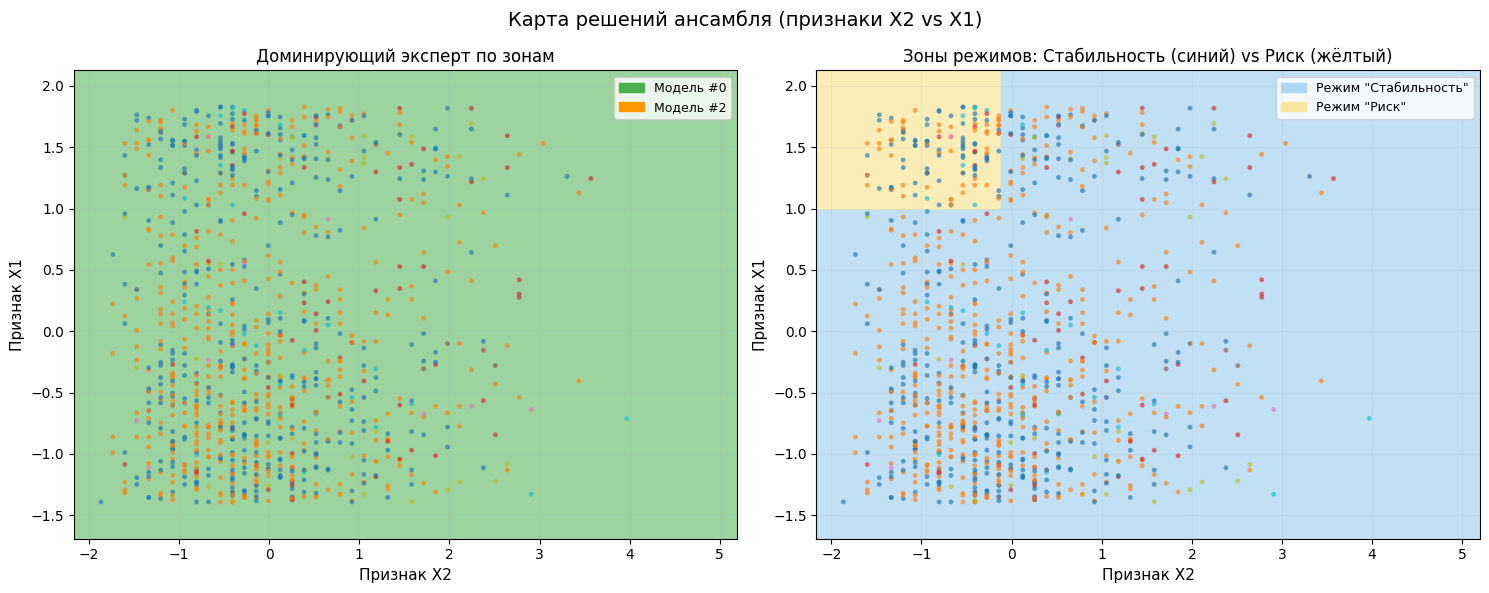

Доля зоны 'Риск': 8.4%,  'Стабильность': 91.6%


In [12]:
fa, fb = MAP_FEAT_A, MAP_FEAT_B

# Границы по реальным данным val-набора
x_min, x_max = X_val[:, fa].min() - 0.3, X_val[:, fa].max() + 0.3
y_min, y_max = X_val[:, fb].min() - 0.3, X_val[:, fb].max() + 0.3
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

# Сетка: среднее значение остальных признаков (фиксируем контекст)
grid_pts = np.tile(X_val.mean(axis=0), (xx.ravel().shape[0], 1))
grid_pts[:, fa] = xx.ravel()
grid_pts[:, fb] = yy.ravel()

active_arr    = np.array(best_individual['active_mask'])
active_ids_plot = [i for i, v in enumerate(best_individual['active_mask']) if v == 1]
n_act         = len(active_ids_plot)

# Для каждой точки сетки: предсказание ансамбля (доминирующий класс)
grid_proba = np.array([expert_models[e].predict(grid_pts, verbose=0)
                       for e in range(N_EXPERTS)])

# Предсказание ансамбля по сетке
y_grid_ensemble = apply_strategy(best_individual, grid_pts, grid_proba)

# Доминирующий эксперт: у какого активного наибольшая уверенность в предсказанном классе
dominant = np.zeros(grid_pts.shape[0], dtype=int)
conf_max = np.zeros(grid_pts.shape[0])
for e in active_ids_plot:
    conf = grid_proba[e].max(axis=1)
    mask_better = conf > conf_max
    dominant[mask_better] = e
    conf_max[mask_better] = conf[mask_better]

# Режимы переключения на сетке
sample_group_grid = np.zeros(grid_pts.shape[0], dtype=int)
for (feat, thr, grp) in best_individual['rules']:
    sample_group_grid[grid_pts[:, feat] > thr] = grp

# Цвета для активных моделей
color_palette = ['#4CAF50', '#2196F3', '#FF9800', '#E91E63', '#9C27B0', '#00BCD4']
colors_active = [color_palette[i % len(color_palette)] for i in active_ids_plot]
cmap_active   = ListedColormap(colors_active)

# Перекодируем dominant в 0..n_act-1
dominant_remap = np.zeros_like(dominant)
for rank, eid in enumerate(active_ids_plot):
    dominant_remap[dominant == eid] = rank

Z1 = dominant_remap.reshape(xx.shape)
Z2 = sample_group_grid.reshape(xx.shape)

# Scatter: случайная подвыборка val
rng      = np.random.default_rng(0)
s_idx    = rng.choice(len(X_val), size=min(1000, len(X_val)), replace=False)
scatter_x = X_val[s_idx, fa]
scatter_y = X_val[s_idx, fb]
scatter_c = y_val[s_idx]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"Карта решений ансамбля (признаки X{fa} vs X{fb})", fontsize=14)

# --- Левая: доминирующий эксперт ---
ax = axes[0]
cf1 = ax.contourf(xx, yy, Z1,
                  levels=np.arange(-0.5, n_act, 1),
                  cmap=cmap_active, alpha=0.55)
ax.scatter(scatter_x, scatter_y, c=scatter_c,
           cmap='tab10', s=12, alpha=0.65, edgecolors='none', zorder=3)
ax.set_xlabel(f"Признак X{fa}", fontsize=11)
ax.set_ylabel(f"Признак X{fb}", fontsize=11)
ax.set_title("Доминирующий эксперт по зонам")
patches = [mpatches.Patch(color=colors_active[r], label=f"Модель #{eid}")
           for r, eid in enumerate(active_ids_plot)]
ax.legend(handles=patches, loc='upper right', fontsize=9)
ax.grid(True, alpha=0.15)

# --- Правая: режимы переключения ---
ax = axes[1]
ax.contourf(xx, yy, Z2, levels=[-0.5, 0.5, 1.5],
            colors=['#AED6F1', '#F9E79F'], alpha=0.75)
ax.scatter(scatter_x, scatter_y, c=scatter_c,
           cmap='tab10', s=12, alpha=0.65, edgecolors='none', zorder=3)
ax.set_xlabel(f"Признак X{fa}", fontsize=11)
ax.set_ylabel(f"Признак X{fb}", fontsize=11)
ax.set_title('Зоны режимов: Стабильность (синий) vs Риск (жёлтый)')
p0 = mpatches.Patch(color='#AED6F1', label='Режим "Стабильность"')
p1 = mpatches.Patch(color='#F9E79F', label='Режим "Риск"')
ax.legend(handles=[p0, p1], loc='upper right', fontsize=9)
ax.grid(True, alpha=0.15)

plt.tight_layout()
plt.show()

# Статистика зон
pct_risk = 100 * sample_group_grid.mean()
print(f"Доля зоны 'Риск': {pct_risk:.1f}%,  'Стабильность': {100-pct_risk:.1f}%")


## 13. Сравнение: ансамбль vs одиночные модели (bar plot)

Вычисляем точность всех экспертов на тест-наборе...
  Модель #0: 0.7722
  Модель #1: 0.6950
  Модель #2: 0.6477
  Модель #3: 0.6733
  Модель #4: 0.6945
  Модель #5: 0.6990


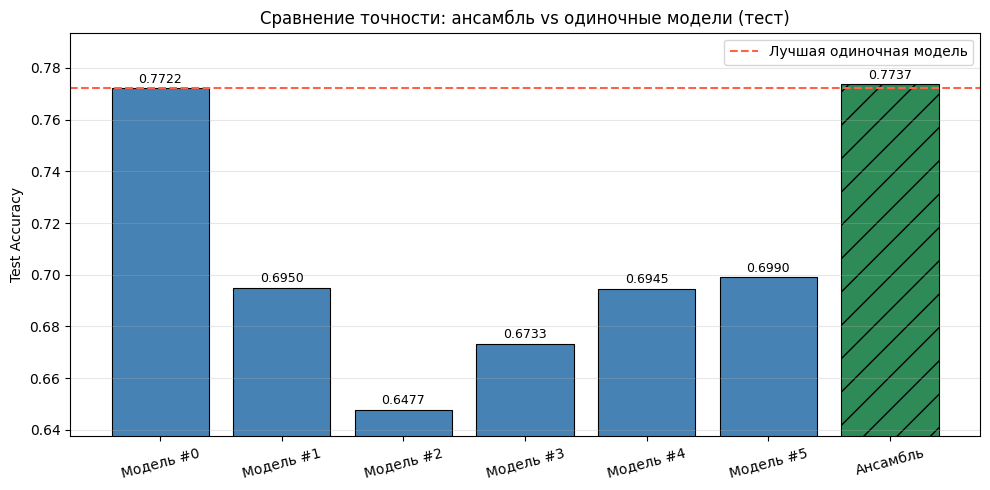

In [13]:
print("Вычисляем точность всех экспертов на тест-наборе...")
single_test_accs = []
for i, m in enumerate(expert_models):
    y_pr = np.argmax(m.predict(X_test, verbose=0), axis=1)
    a    = accuracy_score(y_test, y_pr)
    single_test_accs.append(a)
    print(f"  Модель #{i}: {a:.4f}")

labels     = [f"Модель #{i}" for i in range(N_EXPERTS)] + ["Ансамбль"]
values     = single_test_accs + [acc_ensemble]
colors_bar = ['steelblue'] * N_EXPERTS + ['seagreen']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, values, color=colors_bar, edgecolor='black', linewidth=0.8)
bars[-1].set_hatch('/')

ax.axhline(max(single_test_accs), color='tomato', linestyle='--',
           linewidth=1.5, label='Лучшая одиночная модель')

for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.001,
            f"{v:.4f}", ha='center', va='bottom', fontsize=9)

ax.set_ylim(min(values) - 0.01, max(values) + 0.02)
ax.set_ylabel("Test Accuracy")
ax.set_title("Сравнение точности: ансамбль vs одиночные модели (тест)")
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 14. Анализ ошибок

Исследуем, **в каких областях признакового пространства** ансамбль ошибается чаще, чем лучшая одиночная модель.


In [14]:
err_ensemble = (y_pred_ensemble != y_test).astype(int)
err_single   = (y_pred_single   != y_test).astype(int)

worse_mask  = (err_ensemble - err_single) > 0
better_mask = (err_ensemble - err_single) < 0

print(f"Образцов, где ансамбль хуже одиночной: {worse_mask.sum()} "
      f"({100 * worse_mask.mean():.1f}%)")
print(f"Образцов, где ансамбль лучше одиночной: {better_mask.sum()} "
      f"({100 * better_mask.mean():.1f}%)")

CLASS_NAMES = [
    'Spruce/Fir', 'Lodgepole Pine', 'Ponderosa Pine',
    'Cottonwood/Willow', 'Aspen', 'Douglas-fir', 'Krummholz'
]

print()
print("Ошибки по классам:")
header = f"  {'Класс':<22} {'Ансамбль':>12} {'Одиночная':>12} {'Дельта':>10}"
print(header)
for cls in range(N_CLASSES):
    cls_mask = y_test == cls
    a_err = err_ensemble[cls_mask].mean()
    s_err = err_single[cls_mask].mean()
    print(f"  {CLASS_NAMES[cls]:<22} {a_err:>12.4f} {s_err:>12.4f} {a_err - s_err:>+10.4f}")

Образцов, где ансамбль хуже одиночной: 19 (0.3%)
Образцов, где ансамбль лучше одиночной: 28 (0.5%)

Ошибки по классам:
  Класс                      Ансамбль    Одиночная     Дельта
  Spruce/Fir                   0.2674       0.2783    -0.0110
  Lodgepole Pine               0.1282       0.1234    +0.0048
  Ponderosa Pine               0.1463       0.1518    -0.0054
  Cottonwood/Willow            0.8929       0.8929    +0.0000
  Aspen                        0.9082       0.9082    +0.0000
  Douglas-fir                  0.8268       0.8101    +0.0168
  Krummholz                    0.3868       0.3868    +0.0000


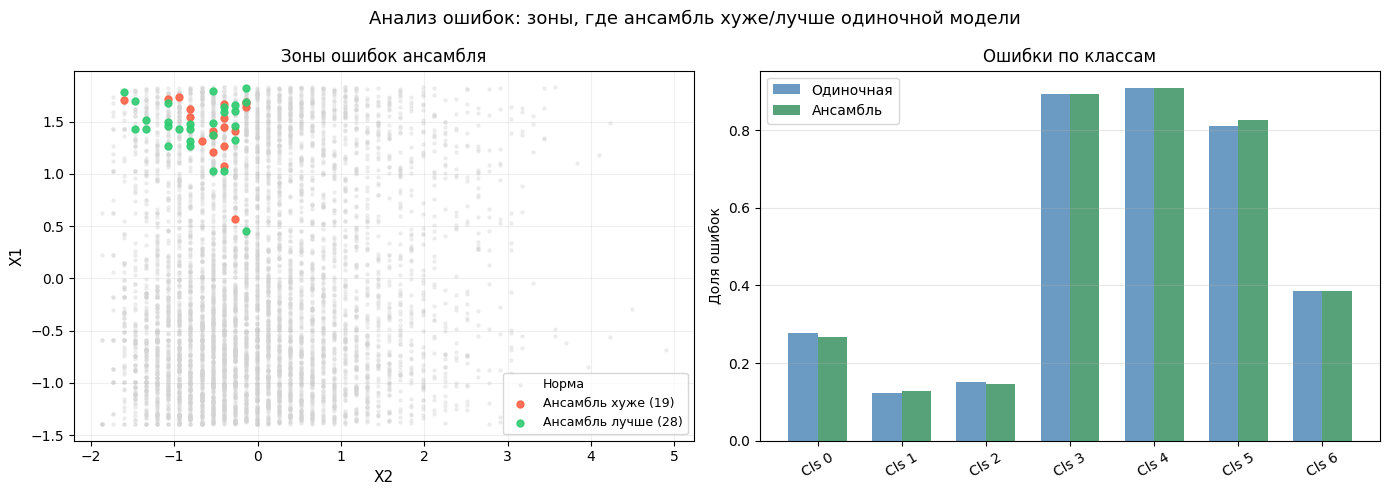


Краткий анализ:
  Наибольшая разница ошибок — класс 5 (Douglas-fir).
  Ансамбль хуже одиночной на 19 образцах (0.3%) тестовой выборки.
  Ансамбль лучше одиночной на 28 образцах (0.5%) тестовой выборки.
  Вероятная причина: конфликт прогнозов активных моделей вблизи порога X7=1.38.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Анализ ошибок: зоны, где ансамбль хуже/лучше одиночной модели", fontsize=13)

fa, fb = MAP_FEAT_A, MAP_FEAT_B

ax = axes[0]
ok_mask = ~worse_mask & ~better_mask
ax.scatter(X_test[ok_mask, fa], X_test[ok_mask, fb],
           c='lightgray', s=5, alpha=0.3, label='Норма', rasterized=True)
if worse_mask.sum() > 0:
    ax.scatter(X_test[worse_mask, fa], X_test[worse_mask, fb],
               c='tomato', s=25, alpha=0.9,
               label=f'Ансамбль хуже ({worse_mask.sum()})', zorder=5)
if better_mask.sum() > 0:
    ax.scatter(X_test[better_mask, fa], X_test[better_mask, fb],
               c='#2ECC71', s=25, alpha=0.9,
               label=f'Ансамбль лучше ({better_mask.sum()})', zorder=5)
ax.set_xlabel(f"X{fa}", fontsize=11)
ax.set_ylabel(f"X{fb}", fontsize=11)
ax.set_title("Зоны ошибок ансамбля")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

ax = axes[1]
x_pos    = np.arange(N_CLASSES)
ens_errs = [err_ensemble[y_test == c].mean() for c in range(N_CLASSES)]
sng_errs = [err_single[y_test == c].mean()   for c in range(N_CLASSES)]
w = 0.35
ax.bar(x_pos - w / 2, sng_errs, w, label='Одиночная', color='steelblue', alpha=0.8)
ax.bar(x_pos + w / 2, ens_errs, w, label='Ансамбль',  color='seagreen',  alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels([f"Cls {c}" for c in range(N_CLASSES)], rotation=30)
ax.set_ylabel("Доля ошибок")
ax.set_title("Ошибки по классам")
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nКраткий анализ:")
worst_cls = int(np.argmax([err_ensemble[y_test == c].mean() - err_single[y_test == c].mean()
                            for c in range(N_CLASSES)]))
print(f"  Наибольшая разница ошибок — класс {worst_cls} ({CLASS_NAMES[worst_cls]}).")
print(f"  Ансамбль хуже одиночной на {worse_mask.sum()} образцах "
      f"({100*worse_mask.mean():.1f}%) тестовой выборки.")
print(f"  Ансамбль лучше одиночной на {better_mask.sum()} образцах "
      f"({100*better_mask.mean():.1f}%) тестовой выборки.")
if worse_mask.sum() > 0 and best_individual['rules']:
    feat0, thr0, _ = best_individual['rules'][0]
    print(f"  Вероятная причина: конфликт прогнозов активных моделей "
          f"вблизи порога X{feat0}={thr0:.2f}.")


## 15. Итоговое резюме

In [16]:
active_ids = [i for i, v in enumerate(best_individual['active_mask']) if v == 1]
n_active   = len(active_ids)

print("=" * 65)
print("  ИТОГОВОЕ РЕЗЮМЕ ЛАБОРАТОРНОЙ РАБОТЫ №5")
print("=" * 65)
print()
print(f"  Датасет:              Covertype, {X.shape[0]} образцов, {N_FEATURES} признаков")
print(f"  Пул экспертов:        {N_EXPERTS} моделей")
print(f"  Активных в ансамбле:  {n_active} из {N_EXPERTS}")
print(f"  Активные ID:          {active_ids}")
print()
print(f"  Точность ансамбля (test):         {acc_ensemble:.4f}")
print(f"  Точность лучшей одиночной (test): {acc_single:.4f}")
print(f"  Прирост:                          {acc_ensemble - acc_single:+.4f}")
print()
print("  Логика переключения (правила эволюции):")
for j, (feat, thr, grp) in enumerate(best_individual['rules']):
    mode = '"Риск"' if grp == 1 else '"Стабильность"'
    print(f"    Правило {j + 1}: X{feat} > {thr:.3f}  ->  режим {mode}")
print()
print("  Параметры GA:")
print(f"    Метод:       Генетический алгоритм")
print(f"    Популяция:   {POP_SIZE}")
print(f"    Поколений:   {N_GENERATIONS}")
print(f"    Элитизм:     {ELITE_SIZE}")
print(f"    Мутация:     {MUTATION_RATE}")
print(f"    Кроссовер:   {CROSSOVER_PROB}")
print(f"    Штраф:       {REDUNDANCY_PENALTY} за модель")
print("=" * 65)

  ИТОГОВОЕ РЕЗЮМЕ ЛАБОРАТОРНОЙ РАБОТЫ №5

  Датасет:              Covertype, 29997 образцов, 54 признаков
  Пул экспертов:        6 моделей
  Активных в ансамбле:  2 из 6
  Активные ID:          [0, 2]

  Точность ансамбля (test):         0.7737
  Точность лучшей одиночной (test): 0.7722
  Прирост:                          +0.0015

  Логика переключения (правила эволюции):
    Правило 1: X7 > 1.383  ->  режим "Риск"
    Правило 2: X1 > 0.982  ->  режим "Риск"
    Правило 3: X2 > -0.130  ->  режим "Стабильность"

  Параметры GA:
    Метод:       Генетический алгоритм
    Популяция:   20
    Поколений:   30
    Элитизм:     2
    Мутация:     0.3
    Кроссовер:   0.8
    Штраф:       0.005 за модель
